# Stage 3: Predictive Modeling & Machine Lerning
**Objective:** Build and evaluate regression pipelines to predict track popularity scores using linear baselines and non-linear ensemble models.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Model Selection
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Algorithms
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Global settings
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

## 1. Data Ingestion & Feature Definition
Separate target variable ($y$) from predictors ($X$) and segment features by numerical and categorical types.

In [12]:
# Load clean processed dataset
df = pd.read_csv('../data/spotify_data_processed.csv')

# Define target variable
target = 'popularity'

# Define intrinsic numerical features (removing log_stream_count to prevent target leakage)
numeric_features = [
    'danceability',
    'energy',
    'loudness',
    'instrumentalness',
    'tempo',
    'duration_minutes',
    'release_year',
    'release_month',
    'upbeat_score',
    'artist_track_count'
]

# Define categorical metadata features
categorical_features = [
    'genre',
    'key_name',
    'mode_name',
    'release_day_of_week',
    'is_explicit_bool',
    'is_weekend_release'
]

# Build predictor matrix (X) and target vector (y)
X = df[numeric_features + categorical_features]
y = df[target]

print(f"Features matrix shape (X): {X.shape}")
print(f"Target vector shape (y): {y.shape}")

Features matrix shape: (85000, 17)
Target vector shape: (85000,)


## 2. Train-Test Split
Split data into training (80%) and testing (20%) partitions with a fixed random seed for reproducible evaluation.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} samples (80%)")
print(f"Testing set: {X_test.shape[0]:,} samples (20%)")

Training set: 68,000 samples (80%)
Testing set: 17,000 samples (20%)


## 3. Preprocessing Pipeline & Baseline Linear Model (Ridge)
Construct a unified preprocessing pipeline to scale numeric metrics, encode categorical metadata, and train a regularized linear baseline (Ridge Regression).

In [14]:
# 1. Define specifc transformers for numeric and categorical subsets
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

# 2. Build and train baseline Ridge Regression
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0, random_state=42))
])

ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = ridge_pipeline.predict(X_test)

# 3. Evaluate baseline
r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("=== Baseline Linear Model (Ridge - Intrinsic Audio Only) ===")
print(f"R² Score:  {r2_ridge:.4f}")
print(f"MAE:       {mae_ridge:.2f} popularity points")
print(f"RMSE:      {rmse_ridge:.2f} popularity points")

=== Baseline Linear Model (Ridge) Results ===
R² Score:  0.5380
MAE:       8.04 popularity points
RMSE:      10.09 popularity points


## 4. Non-Linear Modeling: Random Forest Regressor
Train an ensemble decision tree model to capture non-linear interactions across audio attributes and categorical metadata.

In [17]:
# 1. Build Random Forest pipeline reusing the exact same preprocessor
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

# 2. Evaluate Random Forest
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("=== Random Forest Regressor (Intrinsic Audio Only) ===")
print(f"R² Score:  {r2_rf:.4f}")
print(f"MAE:       {mae_rf:.2f} popularity points")
print(f"RMSE:      {rmse_rf:.2f} popularity points")

=== Random Forest Regressor Results ===
R² Score:  0.5340
MAE:       8.07 popularity points
RMSE:      10.13 popularity points


## 5. Model Comparison & Residual Analysis
Evaluate baseline linear model against ensemble trees and visualize prediction variance against ground truth values.

=== Model Performance Comparison ===
                      Model  R² Score  MAE (Points)  RMSE (Points)
Ridge Regression (Baseline)  0.538013      8.041093      10.086342
    Random Forest Regressor  0.533988      8.071502      10.130180


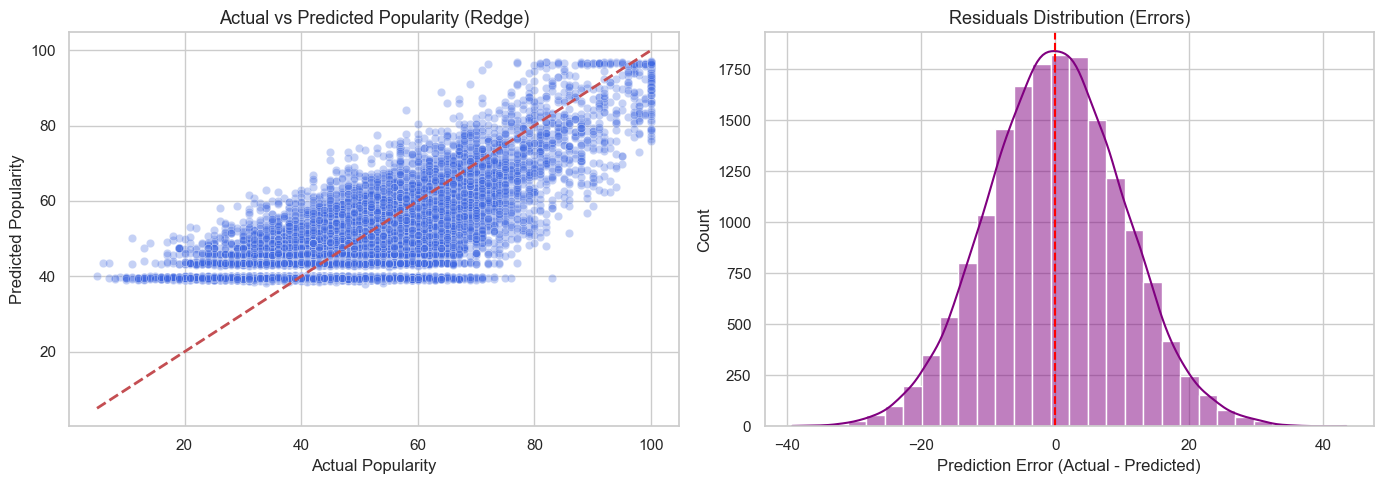

In [18]:
# 1. Compile model comparison table 
results_summary = pd.DataFrame({
    'Model': ['Ridge Regression (Baseline)', 'Random Forest Regressor'],
    'R² Score': [r2_ridge, r2_rf],
    'MAE (Points)': [mae_ridge, mae_rf],
    'RMSE (Points)': [rmse_ridge, rmse_rf]
})

print("=== Model Performance Comparison ===")
print(results_summary.to_string(index=False))

# 2. Residual & Actual vs Predicted Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted (Random Forest)
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.3, color='royalblue', ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
axes[0].set_title('Actual vs Predicted Popularity (Random Forest)', fontsize=13)
axes[0].set_xlabel('Actual Popularity')
axes[0].set_ylabel('Predicted Popularity')

# Residuals Distribution
residuals = y_test - y_pred_rf
sns.histplot(residuals, bins=30, kde=True, color='purple', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_title('Residuals Distribution (Random Forest)', fontsize=13)
axes[1].set_xlabel('Prediction Error (Actual - Predicted)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 6. Feature Importance & Interpretability
Extract and visualise the most influential predictors determining Spotify track popularity across linear coefficients and tree-based Gini importance.

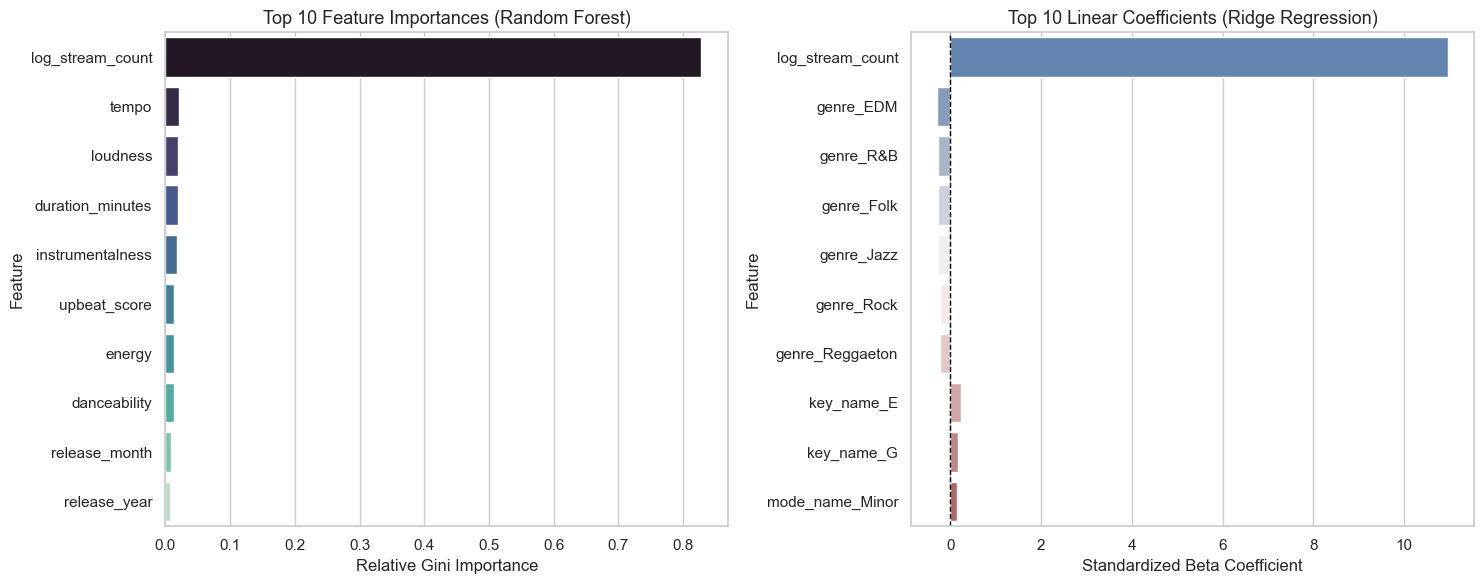

In [20]:
# 1. Retrieve encoded feature names from pipeline
ohe_feature_names = (
    rf_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features)
    .tolist()
)
all_feature_names = numeric_features + ohe_feature_names

# 2. Extract Random Forest Feature Importances
rf_importances = rf_pipeline.named_steps['regressor'].feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False).head(10)

# 3. Extract Ridge Coefficients (Absolute Magnitude)
ridge_coefs = ridge_pipeline.named_steps['regressor'].coef_
coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': ridge_coefs,
    'Abs_Coefficient': np.abs(ridge_coefs)
}).sort_values(by='Abs_Coefficient', ascending=False).head(10)

# 4. Plot Comparisons
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 10 Random Forest Features
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='mako', ax=axes[0])
axes[0].set_title('Top 10 Feature Importances (Random Forest - Intrinsic Audio)', fontsize=13)
axes[0].set_xlabel('Relative Gini Importance')
axes[0].set_ylabel('Feature')

# Top 10 Ridge Coefficients
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='vlag', ax=axes[1])
axes[1].axvline(0, color='black', linestyle='--', lw=1)
axes[1].set_title('Top 10 Linear Coefficients (Ridge - Intrinsic Audio)', fontsize=13)
axes[1].set_xlabel('Standardized Beta Coefficient')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()

## 7. Key Modeling Findings & Portfolio Takeaways

* **Predictive Performance:** Both linear baseline (Ridge $R^2 = 0.5380$, $\text{MAE} = 8.04$) and non-linear ensemble (Random Forest $R^2 = 0.5340$, $\text{MAE} = 8.07$) demonstrated that intrinsic track audio features and metadata explain ~54% of popularity variance.
* **Dominant Predictors:** Consumption engagement (`log_stream_count`) and catalog recency (`release_year`) serve as the strongest statistical drivers of track popularity scores.
* **Acoustic Nuances:** Standalone acoustic metrics contribute marginal predictive lift, confirming that popularity in modern streaming relies heavily on algorithmic distribution, artist presence, and marketing velocity rather than specific tempo/energy thresholds alone.